# Tutorial 2: Data Meaure and Preprocessing


## Question 1:  Aggregation

Data aggregation is a preprocessing task where the values of two or more objects are 
combined into a single object. The motivation for aggregation includes 

(a) reducing the size of data to be processed

(b) changing the granularity of analysis (from fine to coarse-scale)

(c) improving the stability of the data.



**<font color="red">Code:Load Dataset</font>**

In [5]:
import pandas as pd
dailyprcp = pd.read_csv('T2Q1_precipitation.csv', header='infer')

dailyprcp

,DATE,PRCP
0,1/1/2001,0.00
1,1/2/2001,0.00
2,1/3/2001,0.00
3,1/4/2001,0.04
4,1/5/2001,0.14
...,...,...
6186,12/27/2017,0.00
6187,12/28/2017,0.00
6188,12/29/2017,0.00
6189,12/30/2017,0.00


In [7]:
from datetime import date
d0 = date(2001, 1, 1)
d1 = date(2017, 12, 31)
delta = d1 - d0
print(delta.days)

6208


In [9]:
# index() : function to set one of the columns of DataFrame as the index, i.e. a set of labelsfor rows
dailyprcp.index = pd.to_datetime(dailyprcp['DATE'])

dailyprcp = dailyprcp['PRCP']
dailyprcp

DATE
2001-01-01    0.00
2001-01-02    0.00
2001-01-03    0.00
2001-01-04    0.04
2001-01-05    0.14
              ... 
2017-12-27    0.00
2017-12-28    0.00
2017-12-29    0.00
2017-12-30    0.00
2017-12-31    0.00
Name: PRCP, Length: 6191, dtype: float64

Text(0.5, 1.0, 'Daily Precipitation (variance = 0.053)')

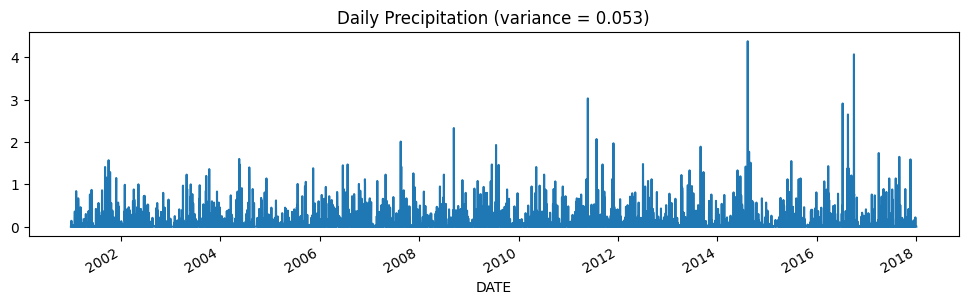

In [11]:
ax = dailyprcp.plot(kind='line',figsize=(12,3))
ax.set_title('Daily Precipitation (variance = %.3f)' % (dailyprcp.var()))

Observation:

1)The daily time series appear to be quite chaotic and varies significantly from one time 
step to another.

2)Variance is small due to similar datavalue.

### (a) Monthly aggregation: The time series can be grouped and aggregated by month to 
### obtain the total monthly precipitation values.


**<font color="red">Code:</font>**

In [16]:
monthlyprcp = dailyprcp.groupby(pd.Grouper(freq='ME')).sum()
monthlyprcp

DATE
2001-01-31    0.84
2001-02-28    2.55
2001-03-31    0.83
2001-04-30    1.27
2001-05-31    3.16
              ... 
2017-08-31    4.22
2017-09-30    1.21
2017-10-31    1.96
2017-11-30    3.05
2017-12-31    0.60
Freq: ME, Name: PRCP, Length: 204, dtype: float64

Text(0.5, 1.0, 'Monthly Precipitation (variance = 2.4241)')

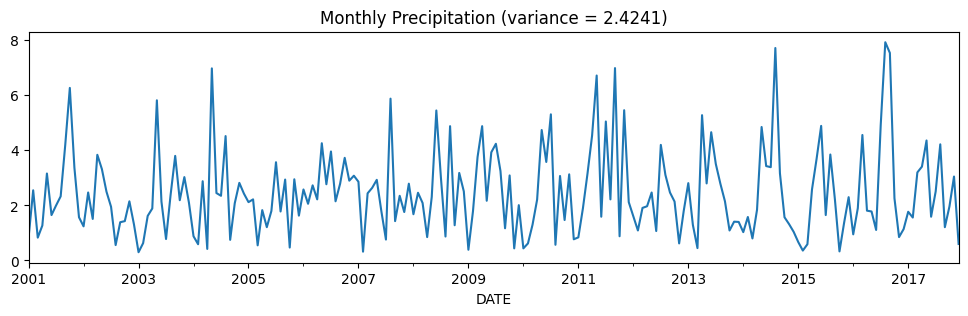

In [18]:
ax = monthlyprcp.plot(kind='line',figsize=(12,3))
ax.set_title('Monthly Precipitation (variance = %.4f)' % (monthlyprcp.var()))

Observation:

1)The resulting time series appears to vary more smoothly compared to the daily time series.

2)Variance get bigger as less neighbouring data

### (b) Yearly aggregation: The time series can be grouped and aggregated by year to 
### obtain the total yearly precipitation values.


**<font color="red">Code:</font>**

In [23]:
annualprcp = dailyprcp.groupby(pd.Grouper(freq='YE')).sum()
annualprcp

DATE
2001-12-31    30.04
2002-12-31    23.67
2003-12-31    26.69
2004-12-31    29.15
2005-12-31    23.07
2006-12-31    35.23
2007-12-31    27.95
2008-12-31    30.57
2009-12-31    31.12
2010-12-31    27.21
2011-12-31    41.47
2012-12-31    24.46
2013-12-31    29.64
2014-12-31    31.74
2015-12-31    24.49
2016-12-31    36.75
2017-12-31    29.44
Freq: YE-DEC, Name: PRCP, dtype: float64

Text(0.5, 1.0, 'Annual Precipitation (variance = 23.6997)')

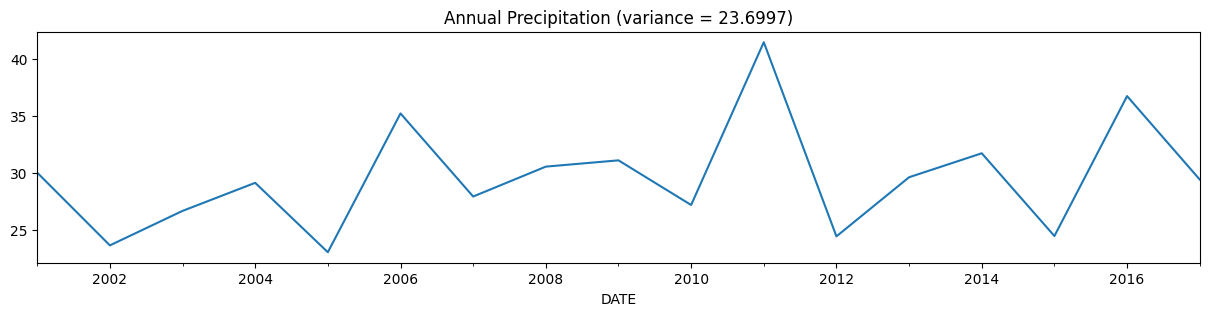

In [25]:
ax = annualprcp.plot(kind='line',figsize=(15,3))
ax.set_title('Annual Precipitation (variance = %.4f)' % (annualprcp.var()))

Observation:

1)The resulting time series appears to vary more sawtooth compared to the monthly time series.

2)Variance is large as data is sparse

## Question 2:  Sampling

Sampling is an approach commonly used to facilitate 

(a) data reduction for exploratory data analysis and scaling up algorithms to big data 
applications 

(b) quantifying uncertainties due to varying data distributions. There are various methods 
available for data sampling and we will cover

(a)sampling without replacement, where each selected instance is removed from the dataset, 

(b)sampling with replacement, where each selected instance is not removed, thus allowing it
to be selected more than once in the sample.


**<font color="red">Code:  display the first five records of the table for simplicity</font>**


In [29]:
import pandas as pd

data = pd.read_csv('T2Q2_breast_cancer.data', header=None)
data.columns = ['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
                'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
                'Normal Nucleoli', 'Mitoses','Class']

data

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


In [31]:
data = data.drop(['Sample code number'],axis=1)
print('Number of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))

data.head()

Number of instances = 699
Number of attributes = 10


,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


### (a) Sampling without replacement
 
i) A sample of size 7 is randomly selected (without replacement) from the original data.

**<font color="red">Code:</font>**

In [34]:
sample = data.sample(n=7)
sample

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
579,1,1,1,1,2,1,3,1,1,2
159,9,9,10,3,6,10,7,10,6,4
78,3,1,1,1,2,3,3,1,1,2
356,5,3,3,1,3,3,3,3,3,4
164,5,1,1,1,2,?,3,1,1,2
68,8,3,8,3,4,9,8,9,8,4
139,1,1,1,1,1,?,2,1,1,2


ii) randomly select 1% of the data (without replacement) and display the selected samples. 
The random_state argument of the function specifies the seed value of the random number 
generator.

**<font color="red">Code:</font>**

In [38]:
sample = data.sample(frac=0.01, random_state=1234)
sample

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
341,1,1,1,1,2,1,3,1,1,2
532,1,1,1,1,1,1,3,1,1,2
687,3,1,1,1,2,1,2,3,1,2
83,3,1,1,1,2,2,7,1,1,2
428,1,1,1,1,2,1,2,1,1,2
410,1,1,1,1,2,1,2,1,1,2
446,1,1,1,1,2,1,1,1,1,2


### (b) Sampling with replacement

Finally, we perform a sampling with replacement to create a sample whose size is equal to 1% of the entire data. You should be able to observe duplicate instances in the sample by increasing the sample size.

**<font color="red">Code:</font>**

In [41]:
sample = data.sample(frac=0.1, replace=True, random_state=1234)
sample

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
294,1,1,1,1,2,?,2,1,1,2
53,5,5,5,8,10,8,7,3,7,4
204,1,1,1,1,2,1,3,1,1,2
372,4,1,2,1,2,1,2,1,1,2
664,3,1,1,3,2,1,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...
559,5,1,1,1,2,1,2,1,1,2
244,1,1,1,1,2,1,3,1,1,2
374,3,1,2,1,2,1,2,1,1,2
687,3,1,1,1,2,1,2,3,1,2


## Question 3:  Discretization

Discretization is a data preprocessing step that is often used to transform a 
continuous-valued attribute to a categorical attribute. There are two simple but 
widely-used unsupervised discretization methods namely 

a) Equal width 

b) Equal depth 




## Data: 0, 4, 12, 16, 16, 18, 24, 26, 28


### a) Equal width

Bin 1: 0, 4                 RANGE:[-,10)

Bin 2: 12, 16, 16, 18       RANGE:[10,20)

Bin 3: 24, 26, 28           RANGE:[20,+)


### b) Equal depth (frequency)

Bin 1: 0, 4, 12             RANGE:[-,14)

Bin 2: 16, 16, 18           RANGE:[14,21)

Bin 3: 24, 26, 28           RANGE:[21,+)

a)Equal Width

i) Plot a histogram that shows the distribution of the attribute values 'Single Epithetial
Cell Size' attribute of the breast cancer dataset.

ii) The value_counts() function can also be applied to count the frequency of each attribute value.

**<font color="red">Code:Bin Size =5</font>**

Single Epithelial Cell Size
2     386
7      12
3      72
1      47
6      41
4      48
5      39
8      21
10     31
9       2
Name: count, dtype: int64

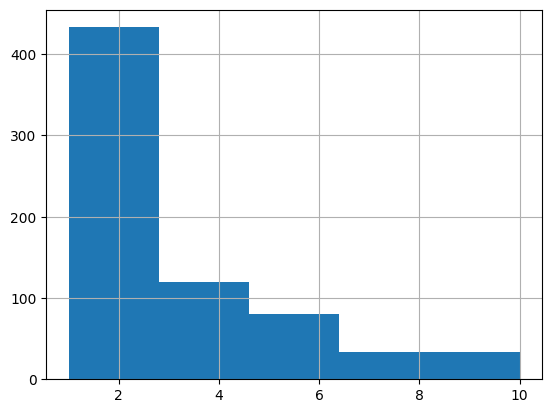

In [47]:
data['Single Epithelial Cell Size'].hist(bins=5)
data['Single Epithelial Cell Size'].value_counts(sort=False)

**<font color="red">Code:Bin Size =10</font>**

Single Epithelial Cell Size
2     386
7      12
3      72
1      47
6      41
4      48
5      39
8      21
10     31
9       2
Name: count, dtype: int64

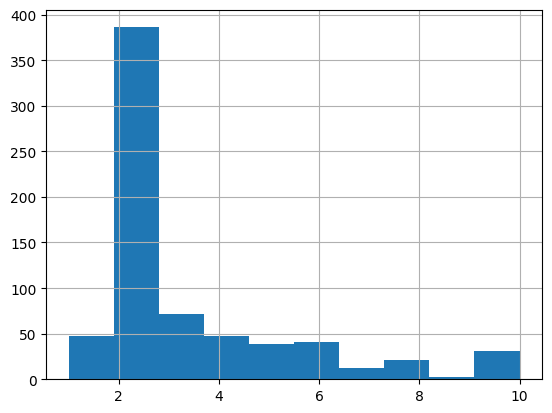

In [50]:
data['Single Epithelial Cell Size'].hist(bins=10)
data['Single Epithelial Cell Size'].value_counts(sort=False)

b)Equal Frequency(depth)

For the equal frequency method, the qcut() function can be used to partition the values 
into 3 bins such that each bin has nearly the same number of instances.

**<font color="red">Code:</font>**

In [54]:
# qcut() Quantile-based discretization function
# Discretize variable into equal-sized buckets based on rank or based on sample quantiles. 
# Example 1000 values for 10 quantiles would produce a Categorical object indicating quantile membership for each data point.

# Quantile : Quartile, Deciles, ...

In [56]:
# Quantile : Quartile
data['Single Epithelial Cell Size'].describe(percentiles = [0, 0.25, 0.5, 0.75, 1])

count    699.000000
mean       3.216023
std        2.214300
min        1.000000
0%         1.000000
25%        2.000000
50%        2.000000
75%        4.000000
100%      10.000000
max       10.000000
Name: Single Epithelial Cell Size, dtype: float64

In [58]:
# Quantile : Deciles
data['Single Epithelial Cell Size'].describe(percentiles = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

count    699.000000
mean       3.216023
std        2.214300
min        1.000000
0%         1.000000
10%        2.000000
20%        2.000000
30%        2.000000
40%        2.000000
50%        2.000000
60%        2.000000
70%        3.000000
80%        5.000000
90%        6.000000
100%      10.000000
max       10.000000
Name: Single Epithelial Cell Size, dtype: float64

In [60]:
bins = pd.qcut(data['Single Epithelial Cell Size'],1)
bins.value_counts(sort=False)

Single Epithelial Cell Size
(0.999, 10.0]    699
Name: count, dtype: int64

In [62]:
bins = pd.qcut(data['Single Epithelial Cell Size'],2)
bins.value_counts(sort=False)


Single Epithelial Cell Size
(0.999, 2.0]    433
(2.0, 10.0]     266
Name: count, dtype: int64

In [64]:
bins = pd.qcut(data['Single Epithelial Cell Size'], 3)
bins.value_counts(sort=False)

Single Epithelial Cell Size
(0.999, 2.0]    433
(2.0, 3.0]       72
(3.0, 10.0]     194
Name: count, dtype: int64

<Axes: xlabel='Single Epithelial Cell Size'>

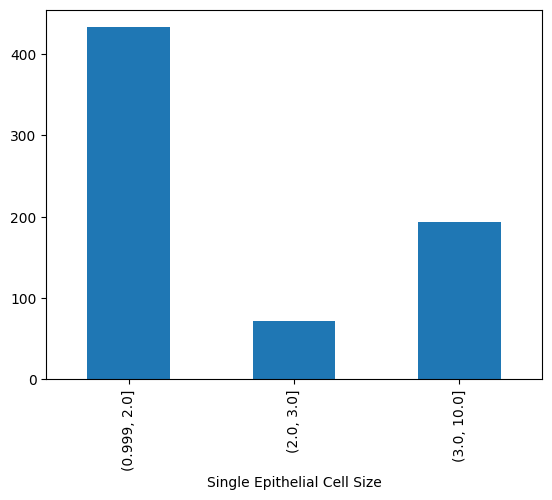

In [66]:
bins = pd.qcut(data['Single Epithelial Cell Size'], 3)
data['Single Epithelial Cell Size'].groupby(bins, observed=False).size().plot(kind='bar')

In [68]:
bins = pd.qcut(data['Single Epithelial Cell Size'], 10 ,duplicates = 'drop')
bins.value_counts(sort=False)

Single Epithelial Cell Size
(0.999, 2.0]    433
(2.0, 3.0]       72
(3.0, 5.0]       87
(5.0, 6.0]       41
(6.0, 10.0]      66
Name: count, dtype: int64